# Mapping the Narrative Journey: A Structural Analysis of Podcast Conversations

**Notebook:** Initial analysis, testing, and implementation of semantic segmentation and topic modeling pipelines.

**Dataset:** SPoRC (Podcast Corpus)

**Goal:** Develop and evaluate methods to segment podcast transcripts into coherent narrative units.

In [ ]:
%pip install -r requirements.txt

## Global imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from umap import UMAP
from hdbscan import HDBSCAN
nltk.download("punkt")

# For topic modeling, graph modeling, visualization
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import plotly.graph_objects as go

c:\Users\Sadik\Desktop\NLP Project\project-milestone-p2-group-10\Tmodel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Analytical Pipeline

**This is an analysis project that applies a sequence of existing NLP techniques to generate novel insights.**

- **Semantic Segmentation:** Transcripts will first be divided into coherent topical segments using text similarity algorithms, identifying natural breakpoints in the conversation.

- **Topic Labeling:** Each segment will be assigned a concise topic label using a powerful topic modeling technique like BERTopic or a Large Language Model for high-quality, human-readable labels.

- **Graph Modeling:** The sequence of topics will be modeled as a directed graph, where nodes represent topics and weighted edges represent the transitions between them. The NetworkX library can be an option for this analysis.

- **Visualization:** The conversational journey will be visualized using topic-flow diagrams (e.g., Sankey diagrams) and graph plots to make the narrative structure intuitive and easy to interpret.

---

Following sections will follow this pipeline Starting with ***Loading the dataset***

## Load and Explore Data

#### Load sample subset of the SPoRC dataset

In [17]:
# Path to your sample file
file_path_episode = r"./episodeLevelDataSample.jsonl"
dataset_sample = pd.read_json(file_path_episode, lines=True) # Reads JSONL line by line

In [ ]:
dataset_sample.head(2)

,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
0,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,Best of SingOut SpeakOut No.3,<p>Best of with snippets from 3 episodes and a...,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,[SPEAKER_00],1.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,60.0,0.0,1.0
1,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,It's All Gone,<p>Simon introduces &apos;It&apos;s all Gone&a...,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,"[SPEAKER_00, SPEAKER_01, SPEAKER_02]",3.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,120.053333,0.0,3.0


#### Preview transcript

In [ ]:
episode = dataset_sample.iloc[4]["transcript"] # the first episodes transcript
print(f" Total length of the transcript: {len(episode)}")

episode

## Semantic Segmentation

**In this section we will test multiple segmentation operation using:**
1. `punkt(e.g. sent_tokenize)` and `SentenceBERT`
2. `wtpsplit` and `SentenceBERT`
3. `neuralTextTiling` algorithm with `SentenceBERT` inspired from *[unsupervised_topic_segmentation](https://github.com/gdamaskinos/unsupervised_topic_segmentation)* by Meta

### Core idea behind each method:

| Algorithm | Core Idea (Analogy) | What it Measures | How it Finds Breaks |
| :--- | :--- | :--- | :--- |
| **`segment_fixed_threshold`** | **"Grading on a Curve"** | Similarity between two adjacent sentences ($`s_i`$ vs. $`s_{i+1}`$). | Finds a single, global threshold (e.g., 25th percentile) and breaks *wherever* the similarity score is below it. |
| **`segment_adaptive`** | **"Finding Local Valleys"** | Similarity between two adjacent sentences ($`s_i`$ vs. $`s_{i+1}`$). | Creates a "topographical map" of similarity. It finds points that are *locally* the bottom of a "valley" (a topic dip) and also *globally* low enough to matter. |
| **`neuralTextTiling` (Improved)** | **"Comparing Landscapes"** | Similarity between two *blocks* of sentences (e.g., $`k=5`$ sentences *before* a gap vs. $`k=5`$ sentences *after*). | Finds gaps where the "topic" of the preceding block is most different from the "topic" of the following block, then finds the deepest "valleys" in *that* graph. |

**1. `segment_fixed_threshold`**

**Core Idea: "Grading on a Curve"**

- This algorithm assumes that topic breaks are simply the "worst" transitions in the text.
- It calculates the similarity for every single adjacent sentence pair (`[0.9, 0.8, 0.4, 0.7, 0.3]`). Then, it sorts them and finds a cutoff point (e.g., the 25th percentile).
- In our example, the 25th percentile score might be 0.35. The algorithm then declares that any transition below 0.35 (the 0.4 and 0.3 scores get flagged) is a break.
- **Limitation:** It's "dumb." It doesn't know why a break is a break; it just knows it's in the bottom 25% of scores.

**2. `segment_adaptive`**

**Core Idea: "Finding Local Valleys"**

- This algorithm is "smarter" because it understands that a "break" is a specific shape on a graph, not just any low score. It looks for valleys.
- A valley has a "bottom" (the break itself, e.g., 0.3) and "sides" (the coherent text before and after, e.g., 0.8 and 0.7).
- It smooths the noisy data to find the real trends, flips the graph, and finds "peaks" (which are "valleys" in the original data).
- **Limitation:** It is still only comparing one sentence to its immediate neighbor (`s_i` vs. `s_i+1`). A single, weird sentence can create a false "valley."


**3. `neuralTextTiling` (Improved)**

**Core Idea: "Comparing Landscapes"**

- This is the "smartest" and most robust method. It completely abandons the `s_i` vs. `s_i+1` comparison.
- It knows that a "topic" isn't contained in one sentence, but in a group of sentences.
- At every possible gap, it stops and looks at the landscape behind (the average topic of the last 5 sentences) and compares it to the landscape ahead (the average topic of the next 5 sentences).
- This creates a new graph, not of sentence-to-sentence similarity, but of block-to-block similarity.
- This new graph is much more stable and gives a truer "topical" map. The rest of the algorithm (smoothing, depth scores) is just a very robust way to find the deepest valleys in this new, high-quality map.
- **Strength:** It's highly resistant to noise. A single "weird" sentence gets averaged out of the 5-sentence block and doesn't create a false break.

### 1. Testing Segmentation with `punkt(e.g. sent_tokenize)` and `SentenceBERT`  (potential alternative: Status: dropped)

Mathematical notation to understand the core logic of the algorithms (1. `segment_fixed_threshold`, 2. `segment_adaptive`, and 3. `segment_coherence`).

**Shared Definitions**

First, let's define the common variables and operations used across the functions.<br>
- Let $T$ be the input text.
- Let $S = (s_0, s_1, \dots, s_{n-1})$ be the sequence of $n$ sentences obtained by tokenizing $T$.
- Let $M$ be the sentence embedding model (e.g., a transformer model).
- Let $e_i = M(s_i)$ be the $d$-dimensional embedding vector for sentence $s_i$.
- Let $\text{sim}(u, v)$ be the cosine similarity between two vectors $u$ and $v$:

$$\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$
Let $C = (c_0, c_1, \dots, c_{n-2})$ be the sequence of $(n-1)$ adjacent similarity scores, where:

$$c_i = \text{sim}(e_i, e_{i+1})$$

This $c_i$ represents the coherence between sentence $s_i$ and $s_{i+1}$.

**A. `segment_fixed_threshold`**

This method segments the text by identifying all points where the adjacent similarity $c_i$ drops below a fixed threshold $\tau$.<br> The threshold $\tau$ is not a static value, but is calculated dynamically as the $p$-th percentile of all similarity scores in the document.<br>
**1. Formulation:**
- Inputs:
    - Text $T$ (which yields $S$ and $C$ as defined above).
    - Percentile value $p$ (e.g., 25).

**2. Calculate Threshold ($\tau$):**
The threshold $\tau$ is the $p$-th percentile of the similarity scores sequence $C$.

$$\tau = P_p(C) = P_p(\{c_0, c_1, \dots, c_{n-2}\})$$
**3. Identify Break Indices ($B$):**
- A break is created at sentence index $i+1$ if the similarity $c_i$ (between $s_i$ and $s_{i+1}$) is less than $\tau$.

$$B = \{ i+1 \mid c_i < \tau, \text{ for } i \in [0, n-2] \}$$
**4. Create Segment Index List ($Idx$):**
The full list of indices for slicing the sentence list $S$ is created by combining the start (0), the end ($n$), and the break indices $B$.

$$Idx = \text{sort}( \{0\} \cup B \cup \{n\} )$$

Let $Idx = (idx_0, idx_1, \dots, idx_m)$, where $idx_0 = 0$ and $idx_m = n$.

**5. Form Segments ($Seg_j$):**
Each segment $Seg_j$ is the concatenation of sentences from $S$, starting from $s_{idx_{j-1}}$ up to (but not including) $s_{idx_j}$.

$$Seg_j = \text{join}(s_k) \quad \text{for} \quad k \in [idx_{j-1}, idx_j - 1]$$
- Output: The set of segments $\{Seg_1, \dots, Seg_m\}$.

**B. `segment_adaptive`**

This method finds topic breaks by identifying "valleys" (local minima) in the coherence signal, rather than using a global threshold.
It first smooths the signal, then finds prominent peaks in the inverted signal (which correspond to valleys), and finally filters these peaks.


**1. Formulation:**
- Inputs:
    - Text $T$ (yielding $S$ and $C$).
    - Window size $w$ (e.g., 3).
    - Prominence $\rho$ (e.g., 0.05).
    - Drop factor $f$ (e.g., 0.85).
    
**2. Smooth Similarity Signal ($C_{smooth}$):**
A smoothed signal $C_{smooth} = (sm_0, \dots, sm_{n-2})$ is computed using a moving average (convolution with a uniform kernel of size $w$).

$$sm_i = \frac{1}{w} \sum_{j = -\lfloor(w-1)/2\rfloor}^{\lfloor w/2 \rfloor} c_{i+j}$$

(Note: This assumes padding at the boundaries, typically $c_k = 0$ or $c_k = c_0 / c_{n-2}$ if $k \notin [0, n-2]$).

**3. Invert Signal ($V$):**
The signal is inverted so that valleys become peaks.

$$v_i = 1 - sm_i \quad \text{for} \quad i \in [0, n-2]$$

**4. Find Prominent Peaks ($P_{idx}$):**
Find the set of indices $P_{idx}$ corresponding to peaks in $V$ that have a prominence of at least $\rho$.

$$P_{idx} = \{ p \mid v_p \text{ is a local maximum in } V \text{ and } \text{prominence}(v_p) \ge \rho \}$$

**5. Filter Peaks ($B$):**
The peaks are filtered to keep only those that represent a significant drop in similarity relative to the document's average.
- First, find the mean of the smoothed signal: $\mu_{sm} = \frac{1}{n-1} \sum_{i=0}^{n-2} sm_i$
- The final set of break indices $B$ is:

$$B = \{ p \mid p \in P_{idx} \text{ and } sm_p < f \cdot \mu_{sm} \}$$

*(Note: As written in the code, $B$ contains indices $p$ from the sim array, not $p+1$ as in the first function. This may be an off-by-one error in the original code, but this is the literal formulation.)*
Create Segment Index List ($Idx$) and Form Segments ($Seg_j$):
This step is identical to steps 4 and 5 from segment_fixed_threshold.

$$Idx = \text{sort}( \{0\} \cup B \cup \{n\} )$$
$$Seg_j = \text{join}(s_k) \quad \text{for} \quad k \in [idx_{j-1}, idx_j - 1]$$
 - Output: The set of segments $\{Seg_1, \dots, Seg_m\}$.

**C. `segment_coherence`**

This function is not a segmentation method, but a metric to evaluate the quality of a given segmentation. It measures the average intra-segment coherence. A good segmentation should have segments where all sentences are highly related to each other.
**1. Formulation:**
- Input:
    - A set of $m$ segments, $\{Seg_1, \dots, Seg_m\}$.

**2. Calculate Coherence for Each Segment ($v_j$):**
For each segment $Seg_j$:
- Tokenize it into its $n_j$ sentences: $S_j = (s_{j,0}, s_{j,1}, \dots, s_{j, n_j-1})$.
- Get embeddings for these sentences: $E_j = (e_{j,0}, \dots, e_{j, n_j-1})$.
- Calculate the set of all unique pairwise similarities within the segment:

$$C_j = \{ \text{sim}(e_{j,i}, e_{j,k}) \mid 0 \le i < k \le n_j-1 \}$$

- The coherence $v_j$ for segment $Seg_j$ is the mean of these similarities. The number of pairs is $\binom{n_j}{2}$.

$$v_j = \text{mean}(C_j) = \frac{1}{\binom{n_j}{2}} \sum_{0 \le i < k \le n_j-1} \text{sim}(e_{j,i}, e_{j,k})$$

(This step is skipped if $n_j < 2$).

**3. Calculate Overall Coherence Score:**
The final score is the average of the individual coherence scores $v_j$ for all segments that were long enough to be scored.

Let $V = \{ v_j \mid n_j \ge 2 \}$.
- Output: $\text{Coherence} = \text{mean}(V) = \frac{1}{|V|} \sum_{v \in V} v$


**Note:** the `segment_coherence` function is flawed. It was intended to measure the robustnes of the segmentation to some extent but by no means this is a valid way of measurement. The function is there just for the convenience.  

In [ ]:
model = SentenceTransformer("all-mpnet-base-v2")

In [6]:
def segment_fixed_threshold(text, model, percentile_threshold=25):
    sents = sent_tokenize(text) #nltk(punkt)
    if len(sents) < 2: 
        return [text], []
    embs = model.encode(sents) #model = SentenceTransformer("all-mpnet-base-v2")
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    threshold = np.percentile(sim, percentile_threshold)    
    breaks = [i + 1 for i, sc in enumerate(sim) if sc < threshold]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, sim


def segment_adaptive(text, model, window=3, prominence=0.05, drop_factor=0.85):
    sents = sent_tokenize(text)
    if len(sents) < 2: 
        return [text], [], []
    embs = model.encode(sents)
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    peaks, _ = find_peaks(inverted, prominence=prominence)
    breaks = [p for p in peaks if smooth[p] < drop_factor * np.mean(smooth)]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, smooth, peaks


def segment_coherence(segments, model):
    vals = []
    for seg in segments:
        sents = sent_tokenize(seg)
        if len(sents) < 2: 
            continue
        embs = model.encode(sents)
        sims = [cosine_similarity([embs[i]], [embs[j]])[0][0]
                for i in range(len(embs)) for j in range(i + 1,len(embs))]
        vals.append(np.mean(sims))
    return np.mean(vals) if vals else 0

def plot_similarity_curve(sim_scores, peaks=None, title="Similarity Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(sim_scores, label="Semantic Similarity")

    if peaks is not None and len(peaks) > 0:
        plt.scatter(peaks, np.array(sim_scores)[peaks], color='red', label='Detected Boundaries')
    
    plt.title(title)
    plt.xlabel("Sentence index")
    plt.ylabel("Cosine similarity")
    plt.legend()
    plt.show()

### 1.1 Testing the hyper parameter for the `segment_adaptive` version

In [ ]:
sample_text = episode
win = [[2, 2, 2, 2, 2, 2], [3, 3, 3, 3, 3, 3], [4, 4, 4, 4, 4, 4], [5, 5, 5, 5, 5, 5], [6, 6, 6, 6, 6, 6]]
prom = [0.06, 0.07, 0.08, 0.09, 0.1]
for j in range(len(win)):
    for i, (window, prominence) in enumerate(zip(win[j], prom), start=1):
        segments, _, _ = segment_adaptive(sample_text, model, window, prominence)
        print(f"{5*'-'} Test {j} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

### 1.2 Testing the hyper parameter for the `segment_fixed_threshold` version

In [ ]:
sample_text = episode
percentile_threshold = [5, 10, 15, 20, 25, 30, 40, 45, 50, 55, 60, 70, 80, 90]
for i, percentile in enumerate(percentile_threshold, start=1):
    segments, _ = segment_fixed_threshold(sample_text, model, percentile)
    print(f"{5*'-'} Test {i} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

### 1.3 Test Semantic Segmentation on a Single Episode

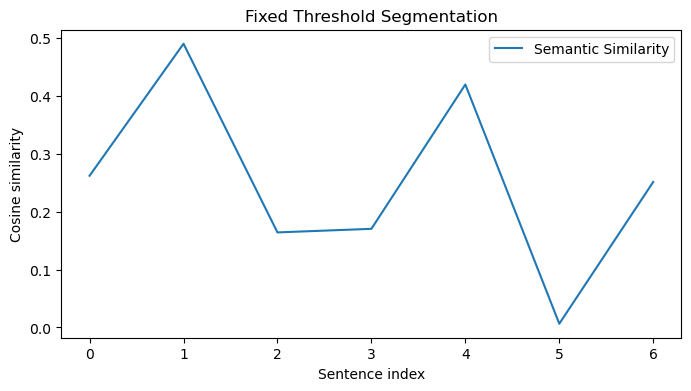

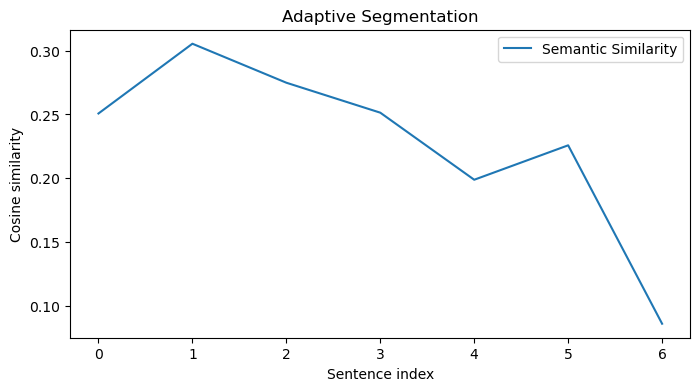

Fixed: 8 segments 
Adaptive: 1 segments
Fixed coherence: 0.000
Adaptive coherence: 0.169


In [7]:
sample_text = episode

segments_fixed, sim_fixed = segment_fixed_threshold(sample_text, model)
segments_adapt, sim_adapt, peaks = segment_adaptive(sample_text, model)

plot_similarity_curve(sim_fixed, title="Fixed Threshold Segmentation")
plot_similarity_curve(sim_adapt, peaks, title="Adaptive Segmentation")

print(f"Fixed: {len(segments_fixed)} segments \nAdaptive: {len(segments_adapt)} segments")
print(f"Fixed coherence: {segment_coherence(segments_fixed, model):.3f}")
print(f"Adaptive coherence: {segment_coherence(segments_adapt, model):.3f}")


In [10]:

print("\n" + "="*30)
print("PODCAST ADAPT_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_adapt):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")

print("\n" + "="*30)
print("PODCAST FIXED_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_fixed):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")


PODCAST ADAPT_SEGMENTATION RESULTS

--- SEGMENT 1 ---

 I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. Hi everyone, welcome to another episode of Sing Out Speak Out. Exciting news today, we have just released, I want to say we, I mean a couple of friends and I who are in this band called Kiss Tone that we have been in for quite a long time and for many reasons we started on this record 12 years ago and are only able to release it now and very excited that we can do it and I'm really looking forward to hearing what you think of it. I'm very proud of this record. We recorded it with the producer now very well established in Nashville producer Lindsey Rhimes 

### 2. Testing segmentation with `wtpsplit` and `SentenceBERT` (potential alternative: Status: dropped)

Here the idea is the same as **B. `segment_adaptive`** only difference is this method uses more robust `wtpsplit` (State-of-the-art sentence segmentation with 12 Transfomer layers) library for ***segment text into sentences*** compared to `nltk(punkt)`.<br>
- requirement:
    - `pip install wtpsplit`

In [11]:

def create_topical_segments(sents, embedding_model, window=3, prominence=0.05, drop_factor=0.85):
    """
    This is the "segment_adaptive" logic, but modified to accept a
    list of pre-split sentences (from wtpsplit) instead of raw text.
    
    This function finds the *thematic* breaks.
    """
    
    print(f"\nAnalyzing {len(sents)} sentences for *topical* breaks...")
    
    if len(sents) < 2: 
        return [" ".join(sents)], [], []
        
    # --- 1. Get Embeddings ---
    # We use the embedding_model (e.g., 'all-mpnet-base-v2') for this
    print("Calculating sentence embeddings...")
    embs = embedding_model.encode(sents, show_progress_bar=True)
    
    # --- 2. Calculate Adjacent Similarities ---
    print("Calculating adjacent sentence similarities...")
    sim = [util.cos_sim(embs[i], embs[i + 1]).item() for i in range(len(embs) - 1)]
    
    # --- 3. Smooth, Invert, and Find Peaks ---
    print("Smoothing signal and finding peaks (topic breaks)...")
    # Use a longer window to find bigger "paragraph" level breaks
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    
    # Find peaks with a minimum prominence
    peaks, _ = find_peaks(inverted, prominence=prominence)
    
    # --- 4. Adaptive Filtering ---
    # Filter peaks to only keep "significant" drops
    mean_sim = np.mean(smooth)
    adaptive_threshold = drop_factor * mean_sim
    
    breaks = [p for p in peaks if smooth[p] < adaptive_threshold]
    
    print(f"Raw similarity scores (sample): {[round(s, 2) for s in sim[:5]]}...")
    print(f"Smoothed signal (sample): {[round(s, 2) for s in smooth[:5]]}...")
    print(f"Found {len(peaks)} local peaks (potential breaks).")
    print(f"Adaptive threshold is: {adaptive_threshold:.4f}")
    print(f"Filtered down to {len(breaks)} significant topical breaks.")

    # --- 5. Create Final Segments ---
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    
    return segs, smooth, peaks


In [12]:
print("Loading 'sat-12l-sm' (wtpsplit) model...")
sat_model = SaT("sat-12l-sm")

# Move to GPU if available
try:
    if torch.cuda.is_available():
        print("CUDA available. Moving SaT to GPU.")
        sat_model.to("cuda")
        sat_model.half()
    else:
        print("SaT running on CPU.")
except Exception as e:
    print(f"GPU setup for SaT failed: {e}")
# --- Load Model 2: The Embedding Model (SentenceTransformer) ---
print("Loading 'all-mpnet-base-v2' (embedding) model...")
# This model is specifically designed to be good at semantic similarity
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
print("All models loaded.")
# --- Sample Data ---
sample_transcript = (
    "Welcome to 'TechForward', I'm your host, Alex. Today we're diving deep into the world of artificial intelligence. "
    "It's a field that's moving at lightning speed. Just last year, we saw models that could write poetry, and now we're seeing AI that can generate photorealistic video. "
    "It's truly a paradigm shift in content creation.\n"
    "But what does this mean for artists and creators? "
    "Many are worried about their jobs being automated. Sarah, you're an expert in AI ethics, what's your take? "
    "Well Alex, it's a valid concern, but I see it more as a tool for augmentation, not replacement. "
    "Think of it like the synthesizer in music - it didn't replace musicians, it created new genres.\n"
    "That's a great point. Let's switch gears a bit. I want to talk about hardware. "
    "None of this amazing AI would be possible without the incredible advancements in GPU technology. "
    "These new tensor cores are specifically designed for matrix multiplication, which is the heart of deep learning. "
    "It's fascinating how software and hardware are co-evolving.\n"
    "Speaking of hardware, I've just been testing the new 'QuantumByte' laptop. "
    "It's got one of these new chips, and the performance is just staggering for such a thin device. "
    "The battery life, however, is another story. I'm getting about half of what they advertised. "
    "That's always the trade-off, isn't it? Power versus longevity. "
    "For our listeners thinking of upgrading, I'd say wait for the second-gen reviews.\n"
    "Absolutely. Okay, before we wrap up, let's look at what's coming next week. "
    "We'll be interviewing the CEO of 'GreenSolar', a company revolutionizing home energy storage. "
    "They claim their new battery technology can power a home for three days straight. "
    "It's a bold claim, and we're going to dig into the science behind it. Thanks for tuning in."
)
# --- STEP 1: Get clean sentences from wtpsplit ---
# We use do_paragraph_segmentation=False to just get *sentences*
print("\n--- STEP 1: Cleaning text with wtpsplit ---")
# --- interchangeably testing with episode data and sample data (e.g. sample_transcript) 
clean_sentences = sat_model.split(episode, do_paragraph_segmentation=False)
print(f"Successfully split text into {len(clean_sentences)} clean sentences.")



# --- STEP 2: Find topical segments from the clean sentences ---
print("\n--- STEP 2: Finding topical segments with adaptive method ---")
# We can tune these parameters. A larger 'window' (e.g., 5) and
# a larger 'prominence' (e.g., 0.1) will find *fewer* and *larger* segments.
topic_segments, _, _ = create_topical_segments(
    clean_sentences, 
    embed_model,
    window=3, 
    prominence=0.05, 
    drop_factor=0.85
)
# --- Print Final Results ---
print("\n" + "="*30)
print("ROBUST TOPICAL SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(topic_segments):
    print(f"--- TOPICAL SEGMENT {i+1} ---\n")
    print(segment.strip())
    print("\n" + "-"*20 + "\n")

Loading 'sat-12l-sm' (wtpsplit) model...
CUDA available. Moving SaT to GPU.
Loading 'all-mpnet-base-v2' (embedding) model...
All models loaded.

--- STEP 1: Cleaning text with wtpsplit ---
Successfully split text into 19 clean sentences.

--- STEP 2: Finding topical segments with adaptive method ---

Analyzing 19 sentences for *topical* breaks...
Calculating sentence embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating adjacent sentence similarities...
Smoothing signal and finding peaks (topic breaks)...
Raw similarity scores (sample): [0.41, 0.45, 0.6, 0.32, 0.29]...
Smoothed signal (sample): [0.29, 0.49, 0.46, 0.4, 0.27]...
Found 1 local peaks (potential breaks).
Adaptive threshold is: 0.2608
Filtered down to 1 significant topical breaks.

ROBUST TOPICAL SEGMENTATION RESULTS

--- TOPICAL SEGMENT 1 ---

I'm Simon Shapiro and this is Sing Out Speak Out.  Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me.  My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out.  Hi everyone, welcome to another episode of Sing Out Speak Out.  Exciting news today, we have just released, I want to say we, I mean a couple of friends and I who are in this band called Kiss Tone that we have 

### 3. Testing segmentation with `neuralTextTiling` algorithm (potential alternative: Status: kept)

**This is the method we will use for our document segmentation**

The previous algorithms were "local," comparing $s_i$ to $s_{i+1}$. 
This TextTiling implementation is "semi-global," as it compares blocks of text.

The core idea is to compute a "boundary score" for each sentence. This score is high if the text before it is semantically different from the text after it. This calculation creates a "timeseries" graph of topic similarity. The rest of the math is just a sophisticated way to find the deepest and most significant "valleys" in that graph.

<br>

**Notation**

 - $S = [s_1, s_2, ..., s_N]$: The list of $N$ filtered sentences.
 - $E = [\vec{e}_1, \vec{e}_2, ..., \vec{e}_N]$: The list of corresponding $d$-dimensional embedding vectors, where $\vec{e}_i \in \mathbb{R}^d$.
 - $k$: The block size (e.g., $k=5$).
 - $\text{sim}(\vec{a}, \vec{b})$: The cosine similarity function, $\frac{\vec{a} \cdot \vec{b}}{\|\vec{a}\| \|\vec{b}\|}$.

<br>

**Step 1: Block Comparison Score (`block_comparison_score`)**

This function computes a "boundary score" $c_i$ for each potential gap.

The function iterates $i$ from $k$ up to $N - k - 1$. For each $i$, it defines two blocks:

1. **Block Before:** The average embedding of the $k$ sentences before $s_i$.

$$\vec{B}_{\text{before}}(i) = \frac{1}{k} \sum_{j=i-k}^{i-1} \vec{e}_j$$

2. **Block After:** The average embedding of the $k$ sentences after $s_i$.

$$\vec{B}_{\text{after}}(i) = \frac{1}{k} \sum_{j=i+1}^{i+k} \vec{e}_j$$
The similarity score $c_i$ for the gap at $s_i$ is the cosine similarity between these two average vectors:

$$c_i = \text{sim}(\vec{B}_{\text{before}}(i), \vec{B}_{\text{after}}(i))$$
This creates a new timeseries $C$ of similarity scores. This list is shorter than the original sentence list.

$$C = [c_k, c_{k+1}, ..., c_{N-k-1}]$$

Let's call the length of this list $m = N - 2k$. So, $C = [y_0, y_1, ..., y_{m-1}]$.

<br>

**Step 2: Smoothing (`smooth`)**

This step applies a moving average filter to $C$ to reduce noise. Let $C_S$ be the smoothed timeseries. For $n$ passes and a window radius $s$:
A single pass of smoothing (with $s=3$, for simplicity) calculates a new score $y'_i$ as:

$$y'_i = \frac{y_{i-1} + y_i + y_{i+1}}{3}$$

(with boundary conditions for $i=0$ and $i=m-1$).
Our code's more general formula for a window radius $s$ is:

$$y'_i = \frac{1}{|W_i|} \sum_{j \in W_i} y_j$$

where $W_i = \{j \mid \max(0, i-s) \le j \le \min(m-1, i+s)\}$. This process is repeated $n$ times.
Let the final, smoothed timeseries be $C_S = [y_0, y_1, ..., y_{m-1}]$.

<br>

**Step 3: Depth Score (`depth_score`)**

This is the most "classic TextTiling" part. For every point $y_i$ in the smoothed graph, it calculates how "deep" the valley is at that point.
For each point $y_i$ (where $0 < i < m-1$):

1. **Find Left Peak ($y_l$):** Find the index $l < i$ of the nearest "peak" to the left. The code does this by starting at $l = i-1$ and "walking left" as long as the score is increasing (i.e., $y_{l-1} > y_l$).

$$l = \min(\{ j \le i-1 \mid (y_{j-1} \le y_j \text{ and } j > 0) \text{ or } j=0 \})$$

2. **Find Right Peak ($y_r$):** Find the index $r > i$ of the nearest "peak" to the right. The code starts at $r = i+1$ and "walks right" as long as the score is increasing (i.e., $y_{r+1} > y_r$).

$$r = \max(\{ j \ge i+1 \mid (y_{j+1} \le y_j \text{ and } j < m-1) \text{ or } j=m-1 \})$$

3. **Calculate Depth ($d_i$):** The depth score is the sum of the heights of the "cliffs" on either side of the valley.

$$d_i = (y_l - y_i) + (y_r - y_i)$$
This creates a new list of depth scores $D = [d_1, ..., d_{m-2}]$.

<br>

**Step 4: Breakpoint Identification (`Thresholding`)**

Now we find the peaks of the depth_score graph. A "peak" here corresponds to the bottom of the deepest valley in the similarity graph.

1. **Find Local Maxima:** Find all indices $i$ in $D$ that are local peaks.

$$I_{\text{max}} = \{i \mid d_{i-1} < d_i \text{ and } d_i > d_{i+1}\}$$

2. **Find Max Depth:** Find the single highest depth score from these peaks.

$$d_{\max} = \max_{i \in I_{\text{max}}}(d_i)$$

3. **Calculate Threshold:** Create an adaptive threshold based on $d_{\max}$.

$$D_{\text{thresh}} = \text{threshold\_factor} \times d_{\max}$$
4. **Filter Peaks:** The final set of break indices (relative to $D$) are those peaks that clear the threshold.

$$I_{\text{breaks}} = \{i \in I_{\max} \mid d_i > D_{\text{thresh}}\}$$

<br>

**Step 5: Index Mapping**

This final step maps the indices from $I_{\text{breaks}}$ back to the original sentence list $S$.
Let's trace an index $\text{idx} \in I_{\text{breaks}}$:
- $\text{idx}$ is an index into the depth score list $D$.
- $D$ starts at index 1 of the smoothed list $C_S$. So, $\text{idx}$ corresponds to $\text{idx}+1$ in $C_S$.
- $C_S$ has the same indices as the similarity list $C$. So this is $\text{idx}+1$ in $C$.
- The similarity list $C$ starts at sentence $k$. An index $j$ in $C$ corresponds to the score for sentence $s_{k+j}$.
- Therefore, our index $\text{idx}+1$ in $C$ corresponds to the original sentence:

$$\text{Sentence Index} = k + (\text{idx} + 1)$$


In [ ]:
from wtpsplit import SaT
from sentence_transformers import SentenceTransformer, util
# --- Model Loading ---
# We load both models globally to be efficient.

# Model 1: For splitting text into clean sentences
print("Loading 'sat-12l-sm' (wtpsplit) model...")
sat_model = SaT("sat-12l-sm")

# Model 2: For getting sentence embeddings
print("Loading 'all-mpnet-base-v2' (embedding) model...")
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Move models to GPU if available
try:
    if torch.cuda.is_available():
        print("CUDA available. Moving models to GPU.")
        sat_model.to("cuda")
        sat_model.half()
        embed_model.to("cuda")
    else:
        print("Running on CPU.")
except Exception as e:
    print(f"GPU setup failed: {e}")

# --- TextTiling Algorithm Functions (from paper) ---

def block_comparison_score(embs_stack, k=10): # <-- PARAMETER RENAMED
    """
    Implements the block comparison from TextTiling.
    Calculates similarity score for each "gap" between sentences.
    
    Args:
        embs_stack (torch.Tensor): A 2D Tensor of (num_sentences, emb_dim).
                                   This is PRE-STACKED.
        k (int): The block size (number of sentences to compare on
                 either side of the gap).
    
    Returns:
        list[float]: A list of similarity scores.
    """
    if len(embs_stack) < k * 2:
        # Not enough sentences to compare
        return []
        
    scores = []
    
    # Iterate from the first possible gap (after k sentences)
    # to the last possible gap (before k sentences from the end)
    for i in range(k, len(embs_stack) - k):
        # Score gap at (i): compare [s(i-k)...s(i-1)] with [s(i+1)...s(i+k)].
        
        # Block before: k sentences ending at i
        block_before = embs_stack[i-k : i]
        
        # Block after: k sentences starting at i+1
        block_after = embs_stack[i+1 : i+k+1]
        
        # Pool the embeddings (average) to get a topic vector
        pool_before = torch.mean(block_before, dim=0)
        pool_after = torch.mean(block_after, dim=0)
        
        # Calculate cosine similarity
        sim = util.cos_sim(pool_before, pool_after).item()
        scores.append(sim)
        
    return scores

def depth_score(timeseries):
    """
    Calculates the "depth" of each valley (potential break).
    A deep valley means a significant topic change.
    (This function is a direct implementation from the paper's core.py)
    """
    depth_scores = []
    for i in range(1, len(timeseries) - 1):
        left, right = i - 1, i + 1
        while left > 0 and timeseries[left - 1] > timeseries[left]:
            left -= 1
        while (
            right < (len(timeseries) - 1) and timeseries[right + 1] > timeseries[right]
        ):
            right += 1
        
        # Score is the sum of the "cliffs" on either side
        depth = (timeseries[left] - timeseries[i]) + (timeseries[right] - timeseries[i])
        depth_scores.append(depth)
    return depth_scores

def smooth(timeseries, n=2, s=1):
    """
    Applies a simple moving average filter.
    (This function is from the paper's core.py)
    """
    if not timeseries:
        return []
    smoothed_timeseries = timeseries[:]
    for _ in range(n):
        for index in range(len(smoothed_timeseries)):
            neighbours = smoothed_timeseries[
                max(0, index - s) : min(len(timeseries) - 1, index + s) + 1
            ]
            smoothed_timeseries[index] = sum(neighbours) / len(neighbours)
    return smoothed_timeseries

def get_local_maxima(array):
    """
    Finds local maxima (peaks) in a list.
    (This function is from the paper's core.py)
    """
    local_maxima_indices = []
    local_maxima_values = []
    for i in range(1, len(array) - 1):
        if array[i - 1] < array[i] and array[i] > array[i + 1]:
            local_maxima_indices.append(i)
            local_maxima_values.append(array[i])
    return local_maxima_indices, local_maxima_values

# --- Main Segmentation Function ---

def find_topical_segments(
    text, 
    k=5, 
    min_sentence_len=4,
    smooth_passes=1, 
    smooth_window=1, 
    threshold_factor=0.6
):
    """
    Combines all steps into the full hybrid pipeline.
    
    Args:
        text (str): The full podcast transcript.
        k (int): The block size for TextTiling.
        min_sentence_len (int): Filter out sentences shorter than this.
        smooth_passes (int): Number of smoothing passes.
        smooth_window (int): Window size for smoothing.
        threshold_factor (float): Threshold for break detection, as a
                                  factor of the max depth score.
    
    Returns:
        list[str]: The final list of topic segments.
        dict: A dictionary of intermediate scores for plotting.
    """
    
    # --- Step 1: Clean sentences with wtpsplit ---
    print("\n--- 1. Cleaning text with wtpsplit ---")
    sents = sat_model.split(text, do_paragraph_segmentation=False)
    print(f"Found {len(sents)} raw sentences.")

    # --- Step 2: Pre-process and Filter (CRITICAL) ---
    # This is from the paper: filter out very short,
    # non-semantic "noise" sentences.
    original_sents = sents
    sents = [s.strip() for s in sents if len(s.split()) > min_sentence_len]
    print(f"Filtered down to {len(sents)} sentences (>{min_sentence_len} words).")
    
    if len(sents) < k * 2:
        print("Not enough sentences to perform segmentation.")
        return [" ".join(original_sents)], {}
    
    # --- Step 3: Get Embeddings ---
    print("\n--- 2. Calculating Embeddings ---")
    embs = embed_model.encode(
        sents, 
        convert_to_tensor=True, 
        show_progress_bar=True
    )

    # --- Step 4: Run TextTiling Algorithm ---
    print("\n--- 3. Running TextTiling Algorithm ---")
    
    # 4a. Get block comparison scores
    sim_scores = block_comparison_score(embs, k=k) # 'embs' is already a stack
    
    # 4b. Smooth the scores
    smooth_scores = smooth(sim_scores, n=smooth_passes, s=smooth_window)
    
    # 4c. Calculate "depth" of valleys
    depth_scores = depth_score(smooth_scores)
    
    print(f"Calculated {len(sim_scores)} block similarity scores.")
    print(f"Calculated {len(depth_scores)} depth scores.")

    # --- Step 5: Find Breakpoints (Thresholding) ---
    print("\n--- 4. Finding Breakpoints ---")
    
    # Find the peaks of the depth scores
    local_maxima_indices, local_maxima_values = get_local_maxima(depth_scores)
    
    if not local_maxima_values:
        print("No significant breaks found.")
        return [" ".join(original_sents)], {}

    # Adaptive threshold:
    # A break must be at least 60% as "deep" as the deepest break.
    threshold = threshold_factor * max(local_maxima_values)
    
    # Find all breaks that pass the threshold
    break_indices = [
        local_maxima_indices[i] 
        for i, val in enumerate(local_maxima_values) 
        if val > threshold
    ]
    
    print(f"Found {len(local_maxima_indices)} potential breaks.")
    print(f"Max depth score: {max(local_maxima_values):.4f}")
    print(f"Calculated threshold: {threshold:.4f}")
    print(f"Filtered down to {len(break_indices)} final breaks.")

    # --- Step 6: Map indices and create segments ---
    print("\n--- 5. Creating Final Segments ---")
    
    # This maps the depth_score indices back to the original sentence indices.
    # A depth_score index 'idx' corresponds to a sim_score index 'idx+1'.
    # A sim_score index 'idx' corresponds to a sentence gap 'idx+k'.
    final_break_indices = [k + idx + 1 for idx in break_indices]
    
    # Create the final list of "slice" points
    idx_list = sorted(list(set([0] + final_break_indices + [len(sents)])))
    
    segments = []
    for i in range(len(idx_list) - 1):
        start = idx_list[i]
        end = idx_list[i+1]
        segments.append(" ".join(sents[start:end]))
        
    # Data for plotting
    plot_data = {
        'sim_scores': sim_scores,
        'smooth_scores': smooth_scores,
        'depth_scores': depth_scores,
        'threshold': threshold,
        'breaks': break_indices,
        'score_x_axis': list(range(len(depth_scores))),
        'break_x_axis': break_indices
    }
        
    return segments, plot_data

def plot_segmentation_scores(plot_data, k=5):
    """
    Uses matplotlib to visualize the algorithm's scores.
    """
    if not plot_data:
        print("\nNo plot data to show.")
        return
        
    print("\nGenerating plot...")
    
    sim_scores = plot_data['sim_scores']
    smooth_scores = plot_data['smooth_scores']
    depth_scores = plot_data['depth_scores']
    threshold = plot_data['threshold']
    break_x_axis = plot_data['break_x_axis']

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
    fig.suptitle('Hybrid TextTiling Segmentation Analysis', fontsize=16)

    # --- Plot 1: Similarity Scores ---
    # X-axis needs to be offset to align with gaps
    sim_x_axis = [i + k for i in range(len(sim_scores))]
    smooth_x_axis = [i + k for i in range(len(smooth_scores))]

    ax1.plot(sim_x_axis, sim_scores, 'b-', label='Raw Similarity')
    ax1.plot(smooth_x_axis, smooth_scores, 'r-', linewidth=2, label='Smoothed Similarity')
    ax1.set_ylabel('Similarity (Higher is similar)')
    ax1.set_title('Block Similarity Scores (Valleys = Topic Breaks)')
    ax1.legend()
    ax1.grid(True, linestyle=':')

    # --- Plot 2: Depth Scores ---
    # X-axis needs to be offset to align with gaps
    depth_x_axis = [i + k + 1 for i in range(len(depth_scores))]
    
    ax2.plot(depth_x_axis, depth_scores, 'g-', linewidth=2, label='Valley Depth Score')
    ax2.plot(
        depth_x_axis, 
        [threshold] * len(depth_scores), 
        'r--', 
        label=f'Threshold ({threshold:.2f})'
    )
    
    # Plot the breaks we found
    break_points_x = [depth_x_axis[i] for i in break_x_axis]
    break_points_y = [depth_scores[i] for i in break_x_axis]
    ax2.plot(break_points_x, break_points_y, 'kx', markersize=10, mew=3, label='Final Topic Break')
    
    ax2.set_xlabel('Sentence Gap Index')
    ax2.set_ylabel('Depth Score (Higher is better break)')
    ax2.set_title('Depth Score Analysis (Peaks = Topic Breaks)')
    ax2.legend()
    ax2.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("segmentation_plot.png")
    print("Plot saved to segmentation_plot.png")
    # To display the plot in a notebook, you might use plt.show()
    plt.show()


Loading 'sat-12l-sm' (wtpsplit) model...
Loading 'all-mpnet-base-v2' (embedding) model...
GPU setup failed: name 'torch' is not defined


In [ ]:

# --- Set Hyperparameters ---
# For a long podcast, the paper's default of k=15 is better.
K_BLOCK_SIZE = 5           # How many sentences in a block
MIN_SENTENCE_LEN = 3     # Filter sentences shorter than 3 words
SMOOTH_PASSES = 1        # Number of smoothing passes
SMOOTH_WINDOW = 1        # Window for smoothing
THRESHOLD_FACTOR = 0.5   # 0.6 = break must be 60% of max depth

# ----------------------at this point more hyperparameter testing is required--------------------------

# --- C. Run Full Pipeline ---
segments, plot_data = find_topical_segments(
    episode,
    k=K_BLOCK_SIZE,
    min_sentence_len=MIN_SENTENCE_LEN,
    smooth_passes=SMOOTH_PASSES,
    smooth_window=SMOOTH_WINDOW,
    threshold_factor=THRESHOLD_FACTOR
)
# --- D. Print Results ---
print("\n" + "="*30)
print("HYBRID TEXTTILING SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments):
    print(f"--- TOPICAL SEGMENT {i+1} ---\n")
    print(segment.strip())
    print("\n" + "-"*20 + "\n")
# --- E. Plot Results ---
if 'plt' in globals():
    plot_segmentation_scores(plot_data, k=K_BLOCK_SIZE)
else:
    print("\nMatplotlib not installed. Skipping plot.")
    print("To see the plot, run: pip install matplotlib")

<p style="color:red"><strong><em>Overall, the third method for segmentation with more advanced <code>nuralTextTiling Algorithm</code> does much better job at segmenting the transcript with better precision and much much more robust to noise(e.g. 'brilliant', 'aah', 'let me know'...)</em></strong></p> 

# Compact Pipeline Implementation: Project Milestone P3

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from group_by_cat import group_by_category
from merge_data import merge_dateset
from topic_model import topic_modeling
from graph_model import graph_modeling
from zero_shot import zero_shot_prompt
from cycle_breaker import Gcycle_breaker
from sankey_vis import sankey
from custom_tokenizer import ImprovedTokenizer


## Load a subset of SPORC dataset

In [18]:
dataset_sample = pd.read_json(file_path_episode, lines=True) # Reads JSONL line by line

## Step 1 Hervesting the Segment with `harvester.py` 

-------------------------------- **Run the `harvester.py` first** ---------------------------------


The idea is to segment locally and then analyse globally. <br> 
To that end, we divided each episode into optimal segments using the `neural TextTiling` with <br> 
segmentation evaluation algorithm and saved their embeddings and the necessary information in `**.npy**` files respectively.<br> 
This allowed us great flexibility to implement <br> 
other downstream tasks such as topic modeling, semantic velocity and temporal drift analysis.


## Step 2 Dividing the episodes into three categories (e.g. education, health and religion)

After dividing the data it is important to run through Step 3 - 6 categorically. <br>
For example, if you want to do analysis on ***Education***, do that to for every steps strictly. <br>
Only then you start with the next category  

In [5]:
group_by_category(dataset_sample=dataset_sample)

Found 500 files in processed_vectors_sample2500. Starting processing...
Processing complete.
Total files copied to Health: 115
Total files copied to Religion: 81
Total files copied to Education: 81


## Step 3 Merging group data

#### Category: <span style="background-color: #f8c58bff; color: black; padding: 0 5px;">Education</span>

In [ ]:
all_texts, X_embeddings, timestamps = merge_dateset(folder_name = "grouped_education")

Loading data...
Loaded 820 total segments.
Embedding Matrix Shape: (820, 768)


#### Category: <span style="background-color: #7caae7ec; color: black; padding: 0 5px;">Religion</span>

In [ ]:
all_texts, X_embeddings, timestamps = merge_dateset(folder_name = "grouped_religion")

Loading data...
Loaded 730 total segments.
Embedding Matrix Shape: (730, 768)


#### Category: <span style="background-color: #e77c93ec; color: black; padding: 0 5px;">Health</span>

In [ ]:
all_texts, X_embeddings, timestamps = merge_dateset(folder_name = "grouped_health")

Loading data...
Loaded 1020 total segments.
Embedding Matrix Shape: (1020, 768)


## Step 4 Topic Modeling (BERTopic)

In [79]:
topic_model = topic_modeling()
topics, probs = topic_model.fit_transform(all_texts, X_embeddings) # we pass the pre-computed embedding for faster modeling

2025-12-20 11:18:51,617 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-20 11:18:53,355 - BERTopic - Dimensionality - Completed ✓
2025-12-20 11:18:53,355 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-20 11:18:53,398 - BERTopic - Cluster - Completed ✓
2025-12-20 11:18:53,406 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-20 11:18:57,655 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info() #run this to check the initial result from `topic_model`

### 4.1 Topic_model fine tuning (only when topic count is significantly low)

By adjusting UMAP’s `n_neighbors`, <br>
we control how locally or globally the data is interpreted during dimensionality reduction. <br>
Lowering this value uncovers finer-grained clusters and improves topic distinctiveness. <br>

In [69]:
umap_model_new = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
topic_model.umap_model = umap_model_new
topics, probs = topic_model.fit_transform(all_texts, X_embeddings)

2025-12-20 11:09:00,013 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-20 11:09:00,945 - BERTopic - Dimensionality - Completed ✓
2025-12-20 11:09:00,945 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-20 11:09:00,961 - BERTopic - Cluster - Completed ✓
2025-12-20 11:09:00,962 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-20 11:09:03,892 - BERTopic - Representation - Completed ✓


By modifying HDBSCAN’s `min_cluster_size` and <br> switching the `cluster_selection_method` from `eom` to `leaf` further sharpens topic resolution. 

In [70]:

MIN_CLUSTER_SIZE= 10
MIN_SAMPLES = 5
hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=MIN_SAMPLES
)

#Kmeans_model = KMeans(n_clusters=15)
topic_model.hdbscan_model = hdbscan_model
topics, pred = topic_model.fit_transform(all_texts, X_embeddings)
topic_model.get_topic_info()

2025-12-20 11:09:04,551 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-20 11:09:05,510 - BERTopic - Dimensionality - Completed ✓
2025-12-20 11:09:05,511 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-20 11:09:05,524 - BERTopic - Cluster - Completed ✓
2025-12-20 11:09:05,526 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-20 11:09:08,807 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,169,-1_good news_feel like_relationship jesus_fait...,"[good news, feel like, relationship jesus, fai...","[And so, and he desires to do that in the race..."
1,0,72,0_clark said_welcome wake day_welcome wake_set...,"[clark said, welcome wake day, welcome wake, s...","[I love palm trees. I mean, love can mean all..."
2,1,51,1_racial supremacy_white supremacy_negro procl...,"[racial supremacy, white supremacy, negro proc...","[The light of Gazebo. So, speaking of temples..."
3,2,45,2_executive order_police unions_police reform_...,"[executive order, police unions, police reform...",[They are all being charged. They're all arre...
4,3,42,3_peace great_refuge strength present_refuge s...,"[peace great, refuge strength present, refuge ...",[I'm on the throne. Stop holding on and just ...
5,4,38,4_nations uproar_people come place_capital cit...,"[nations uproar, people come place, capital ci...",[The citizens of Montenegro sleep very soundly...
6,5,32,5_addressed crowd_blah blah_address crowd_oppo...,"[addressed crowd, blah blah, address crowd, op...",[But so much of the attack on Christianity has...
7,6,31,6_people know_young people_read acts_matters d...,"[people know, young people, read acts, matters...","[We're good to see you again from last week, w..."
8,7,30,7_human life trumps_value lives_economically v...,"[human life trumps, value lives, economically ...",[Look at verses 1 through 6. This goes from a...
9,8,26,8_rich god_god people_uncommon sense_jesus says,"[rich god, god people, uncommon sense, jesus s...",[Can I close with just thinking a little bit a...


### 4.2 Applying custom tokenizer for improved zero-shot

- For greater control, implemented a custom tokenizer <br> that filters n-grams based on part-of-speech patterns. <br> 
- This removes meaningless combinations and elevates the quality of topic keywords.

In [81]:
topic_model.update_topics(docs=all_texts,vectorizer_model=CountVectorizer(tokenizer=ImprovedTokenizer()))

### 4.3 Apply zero-shot promting (`gemma-3-4b-it-qat`) for human redable labels

Running locally through an LM Studio API server <br> with OpenAI’s client library to generate coherent titles for
each topic.

In [82]:
representation_model = zero_shot_prompt()
topic_model.update_topics(all_texts, representation_model=representation_model)
topic_model.get_topic_info()

100%|██████████| 25/25 [00:59<00:00,  2.39s/it]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,346,-1_General Language Elements,[General Language Elements],[Like it's still like forcing him to sit down ...
1,0,59,0_Podcast Content Analysis,[Podcast Content Analysis],[It's what I stick to because I know from expe...
2,1,44,1_Anxiety and Fear,[Anxiety and Fear],[So that's quite a big difference between thes...
3,2,41,2_Basic Sentence Structure,[Basic Sentence Structure],"[So I know better, that's just age, you know b..."
4,3,37,3_General Conversation,[General Conversation],"[Like you know you're doing this, like just ta..."
5,4,36,4_Sales & Opinions,[Sales & Opinions],"[ Hi everyone, welcome back to Series 2 of Not..."
6,5,36,5_Internal Thought Processes,[Internal Thought Processes],[So we're stuck on trying to fix the problem t...
7,6,35,6_Intermittent Fasting and Weight Loss,[Intermittent Fasting and Weight Loss],[So I want to talk to you about two scenarios....
8,7,34,7_COVID-19 in Africa,[COVID-19 in Africa],"[That the social media companies may also, you..."
9,8,33,8_Radical Life Choices,[Radical Life Choices],[ Welcome to the Own Your Choices on your Li...


## Step 5 Graph Modeling

To model the narrative flow, the sequence of topics was treated as a directed graph, where nodes <br>
represent distinct topics and edges represent chronological transitions.

In [83]:
G = graph_modeling(topic_model, remove_outliers=False) 


Nodes (Topics): 25
Edges (Transitions): 192

--- Top Transitions (Edges) ---
-1_General Language Elements --> -1_General Language Elements : 194 times
0_Podcast Content Analysis --> 0_Podcast Content Analysis : 35 times
2_Basic Sentence Structure --> 2_Basic Sentence Structure : 33 times
6_Intermittent Fasting and Weight Loss --> 6_Intermittent Fasting and Weight Loss : 30 times
1_Anxiety and Fear --> 1_Anxiety and Fear : 26 times
12_Vegan Lifestyle --> 12_Vegan Lifestyle : 23 times
4_Sales & Opinions --> 4_Sales & Opinions : 21 times
7_COVID-19 in Africa --> -1_General Language Elements : 18 times
-1_General Language Elements --> 7_COVID-19 in Africa : 17 times
3_General Conversation --> 3_General Conversation : 16 times

--- New Central Hubs (Degree Centrality) ---
-1_General Language Elements: 2.04
0_Podcast Content Analysis: 1.04
5_Internal Thought Processes: 0.88
9_Business Networking: 0.88
15_Basic Sentence Structure: 0.75


## Step 6 Narrative Structure Analysis

### Topic-wise narretive flow for : <span style="background-color: #f8c58bff; color: black; padding: 0 5px;">Education</span>

In [51]:
sankey(G, Weight=1) # Weight represent the transitional weight of each edge

#### Outlier remover

In [52]:
G_clean = graph_modeling(topic_model, remove_outliers=True)


[Filtering] Successfully removed outlier hub: '-1_Basic Sentence Structure'

Nodes (Topics): 20
Edges (Transitions): 107

--- Top Transitions (Edges) ---
1_Puffin Island Birds --> 1_Puffin Island Birds : 45 times
0_Mental Health Concerns --> 0_Mental Health Concerns : 42 times
2_Police Violence in Chicago --> 2_Police Violence in Chicago : 41 times
7_Air Force Career --> 7_Air Force Career : 26 times
6_Basic Sentence Structure --> 6_Basic Sentence Structure : 25 times
4_Reading Comprehension --> 4_Reading Comprehension : 20 times
3_Personal Choices & Stories --> 3_Personal Choices & Stories : 18 times
12_Massachusetts Real Estate Transactions --> 12_Massachusetts Real Estate Transactions : 18 times
9_General Discussion --> 9_General Discussion : 17 times
15_Poetry and Music --> 15_Poetry and Music : 15 times

--- New Central Hubs (Degree Centrality) ---
8_Business People: 0.95
0_Mental Health Concerns: 0.89
4_Reading Comprehension: 0.89
5_Basic Language Elements: 0.84
3_Personal Choic

#### Narretive flow without outliers

In [ ]:
sankey(G_clean, Weight=1)# Weight represent the transitional weight of each edge

### Topic-wise narretive flow for : <span style="background-color: #7caae7ec; color: black; padding: 0 5px;">Religion</span>

In [ ]:
sankey(G, Weight=1) # Weight represent the transitional weight of each edge

#### Outlier remover

In [76]:
G_clean = graph_modeling(topic_model, remove_outliers=True)


[Filtering] Successfully removed outlier hub: '-1_General Language'

Nodes (Topics): 22
Edges (Transitions): 150

--- Top Transitions (Edges) ---
2_Police Activity --> 2_Police Activity : 39 times
0_Religious Concepts --> 0_Religious Concepts : 32 times
4_Biblical Themes --> 4_Biblical Themes : 27 times
7_Property Ownership --> 7_Property Ownership : 20 times
1_General Conversation --> 1_General Conversation : 18 times
10_General Information --> 10_General Information : 13 times
9_Christianity --> 9_Christianity : 12 times
5_Religious Greatness --> 5_Religious Greatness : 12 times
6_Philippian Theology --> 6_Philippian Theology : 12 times
8_Christian Security --> 8_Christian Security : 11 times

--- New Central Hubs (Degree Centrality) ---
1_General Conversation: 1.33
3_General Communication: 1.14
0_Religious Concepts: 1.10
11_Religious Beliefs: 0.90
6_Philippian Theology: 0.86


#### Narretive flow without outliers

In [ ]:
sankey(G_clean, Weight=1)# Weight represent the transitional weight of each edge

### Topic-wise narretive flow for : <span style="background-color: #e77c93ec; color: black; padding: 0 5px;">Health</span>

In [ ]:
sankey(G, Weight=1) # Weight represent the transitional weight of each edge

#### Outlier remover

In [85]:
G_clean = graph_modeling(topic_model, remove_outliers=True)


[Filtering] Successfully removed outlier hub: '-1_General Language Elements'

Nodes (Topics): 24
Edges (Transitions): 144

--- Top Transitions (Edges) ---
0_Podcast Content Analysis --> 0_Podcast Content Analysis : 35 times
2_Basic Sentence Structure --> 2_Basic Sentence Structure : 33 times
6_Intermittent Fasting and Weight Loss --> 6_Intermittent Fasting and Weight Loss : 30 times
1_Anxiety and Fear --> 1_Anxiety and Fear : 26 times
12_Vegan Lifestyle --> 12_Vegan Lifestyle : 23 times
4_Sales & Opinions --> 4_Sales & Opinions : 21 times
3_General Conversation --> 3_General Conversation : 16 times
5_Internal Thought Processes --> 5_Internal Thought Processes : 13 times
7_COVID-19 in Africa --> 7_COVID-19 in Africa : 12 times
10_People and Things --> 10_People and Things : 12 times

--- New Central Hubs (Degree Centrality) ---
0_Podcast Content Analysis: 1.00
5_Internal Thought Processes: 0.83
9_Business Networking: 0.83
15_Basic Sentence Structure: 0.70
13_Addiction and Alcohol Use: 

#### Narretive flow without outliers

In [86]:
sankey(G_clean, Weight=1) # Weight represent the transitional weight of each edge

## Step 7 Semantic Velocity (Pacing) Analysis

**Concept:** We can measure how "fast" a conversation moves by calculating the distance between consecutive segment vectors.

- The Logic:

    - If Segment A and Segment B are semantically very close (low Euclidean distance), the speaker is dwelling on a point, repeating themselves, or going deep. (Low Velocity).

    - If Segment A and Segment B are far apart, the speaker is jumping to a completely new idea. (High Velocity).

In [19]:
from semantic_velocity import analyze_semantic_velocity, plot_pacing_analysis

#### Category: <span style="background-color: #f8c58bff; color: black; padding: 0 5px;">Education</span>

Analyzing pacing for 81 episodes...


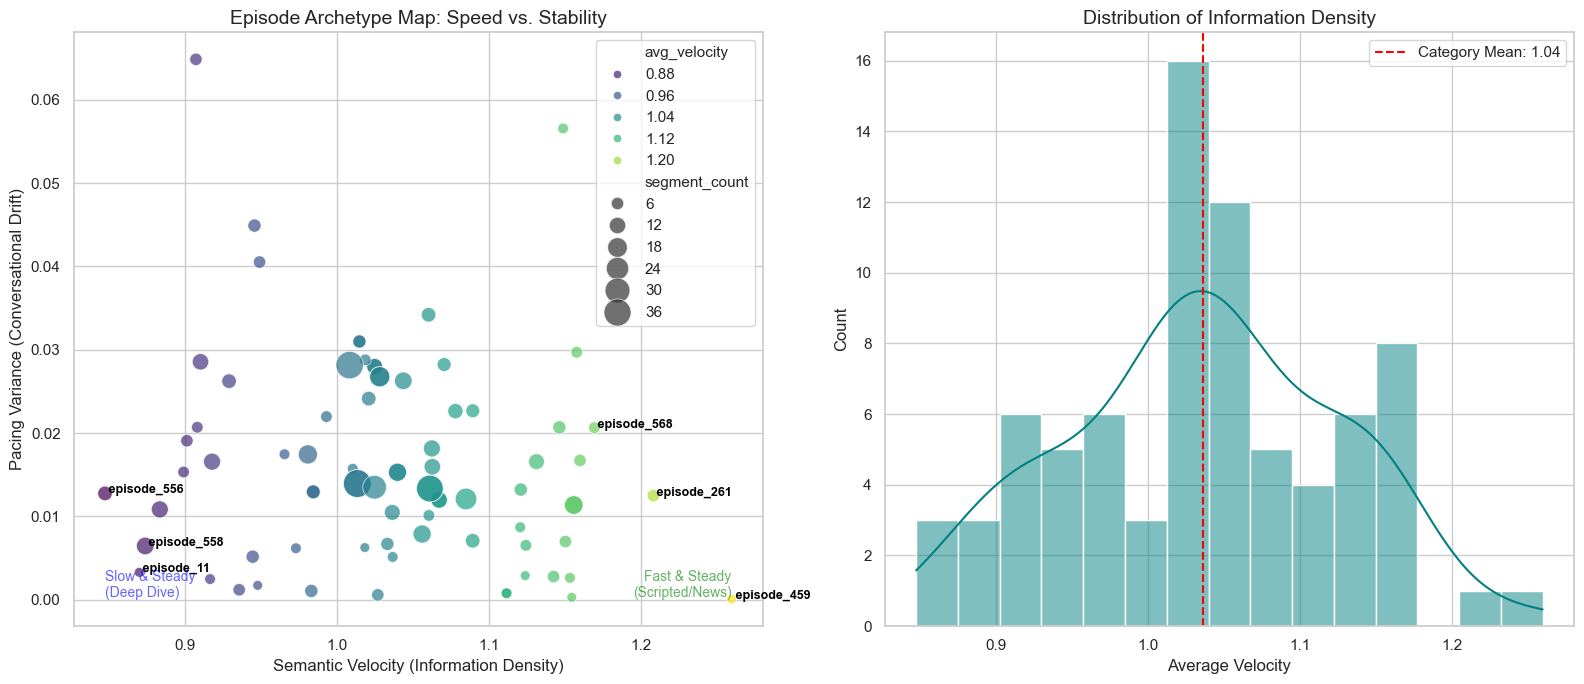

In [54]:

# --- EXECUTION ---
# 1. Run Analysis
df_pacing = analyze_semantic_velocity("grouped_education")

# 2. Generate Plot
plot_pacing_analysis(df_pacing)

#### Category: <span style="background-color: #7caae7ec; color: black; padding: 0 5px;">Religion</span>

Analyzing pacing for 81 episodes...


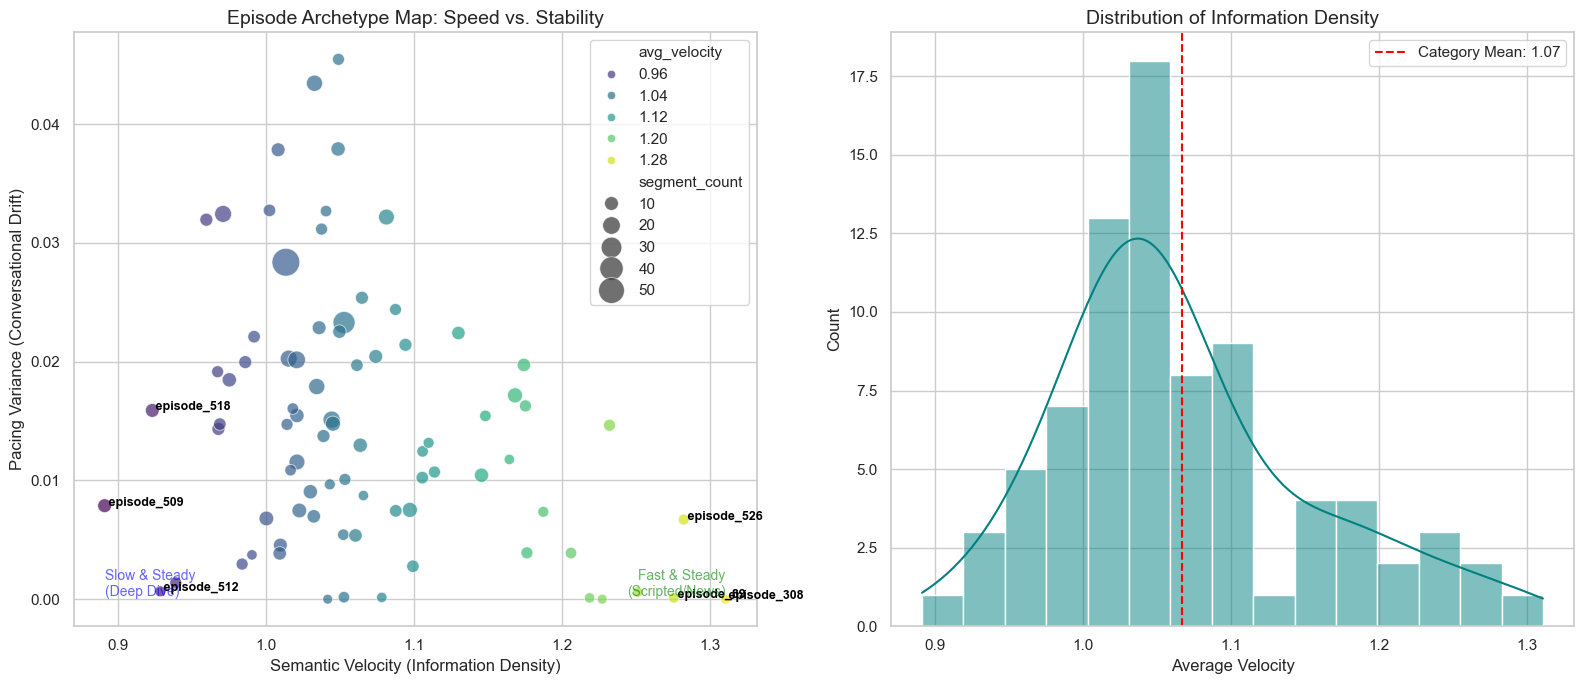

In [64]:
# --- EXECUTION ---
# 1. Run Analysis
df_pacing = analyze_semantic_velocity("grouped_religion")

# 2. Generate Plot
plot_pacing_analysis(df_pacing)

#### Category: <span style="background-color: #e77c93ec; color: black; padding: 0 5px;">Health</span>

Analyzing pacing for 115 episodes...


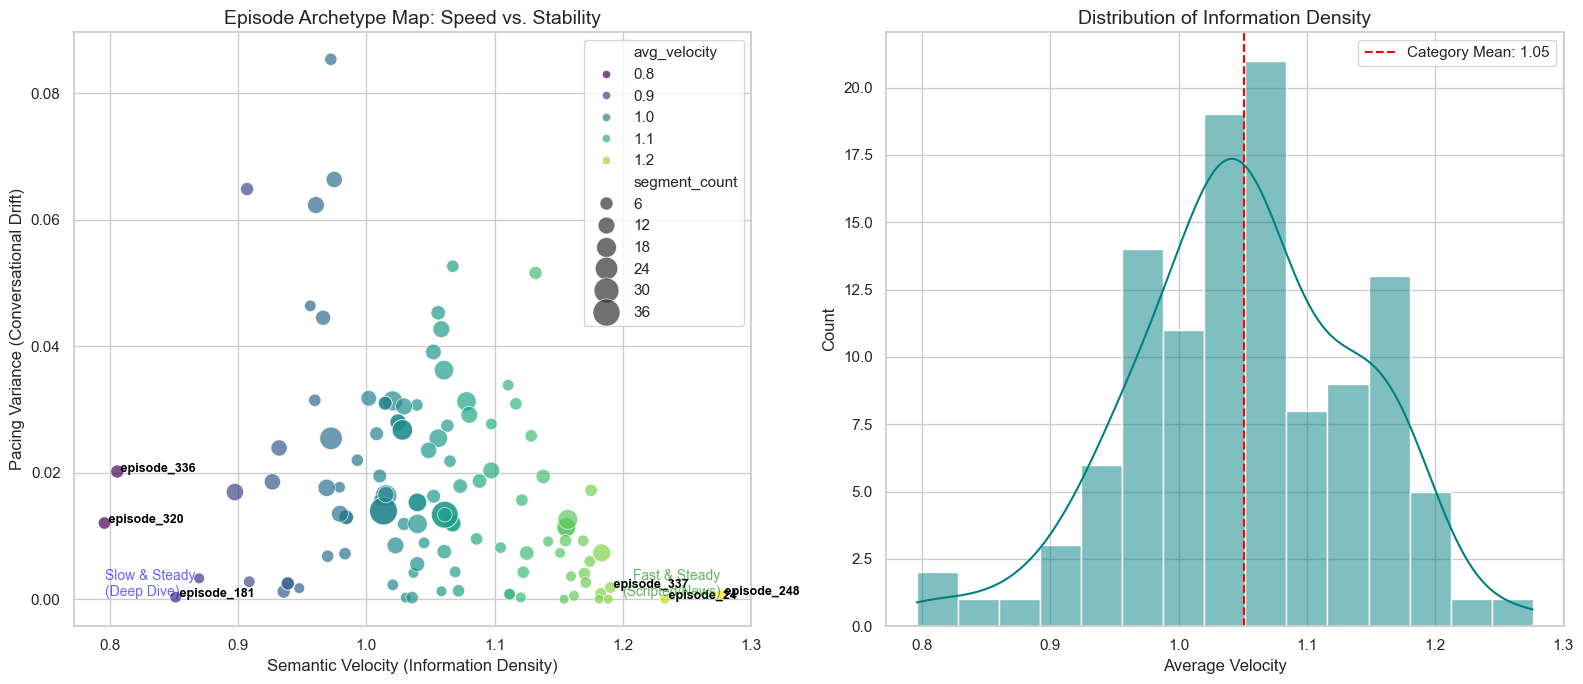

In [65]:
# --- EXECUTION ---
# 1. Run Analysis
df_pacing = analyze_semantic_velocity("grouped_health")

# 2. Generate Plot
plot_pacing_analysis(df_pacing)

## Step 8 Temporal Drift Analysis and Diagnostics

**Concept:** For example, the concept of "Education" as a physical object floating in space.

- In 2010, the "average" Education podcast might have focused on University, History, and Books.

- In 2024, the "average" Education podcast might focus on Online Courses, AI, and Mental Health.

The "Centroid" (the mathematical center) of the Education cluster has moved. Analyzing this movement allows us to quantify:

1. Speed of Evolution: Is the definition of "Education" changing rapidly, or is it stagnant?

2. Trajectory: If we project this movement, where is it heading?

3. Vocabulary Shift: You can eventually find which specific words/topics are pulling the centroid in a new direction.

In [33]:
from temp_drift import analyze_temporal_drift
from drift_diagnostics import explain_drift_drivers

#### Temporal Analysis: <span style="background-color: #f8c58bff; color: black; padding: 0 5px;">Education</span>

--- Loading Data from grouped_education ---
Loaded 81 episodes across 5 years.


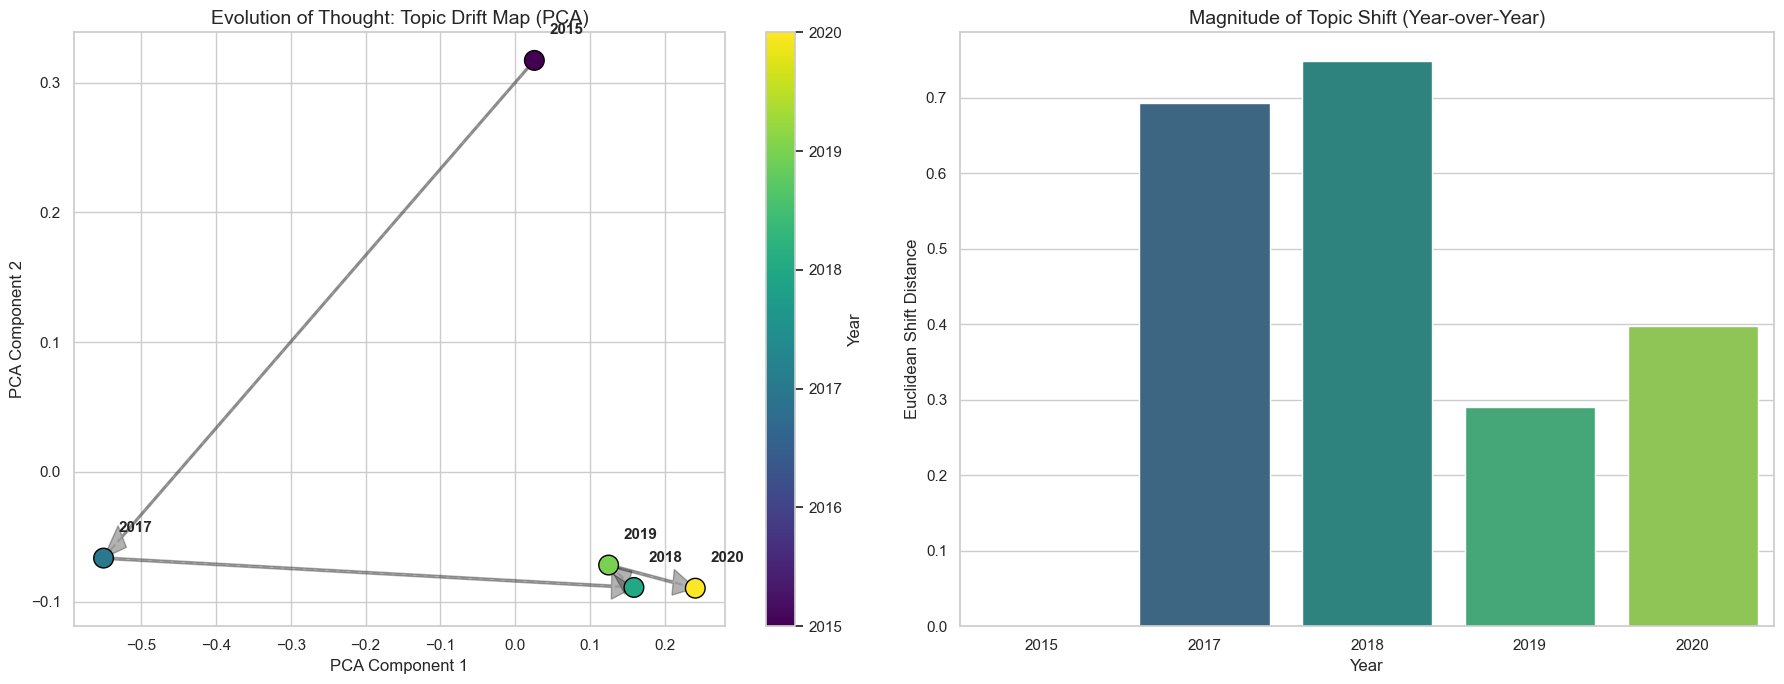

In [55]:
# --- EXECUTION ---
# Point this to one of your category folders
analyze_temporal_drift("grouped_education")

#### Drifting Diagnostics <span style="background-color: #f8c58bff; color: black; padding: 0 5px;">Education</span>

In [56]:
df_words = explain_drift_drivers("grouped_education")

--- Extracting Vocabulary Drivers for grouped_education ---
Analyzing 5 years of content: [2015, 2017, 2018, 2019, 2020]

  KEYWORD EVOLUTION (Distinctive Terms)

📅 2015: police, poem, violence, chicago, internationalization, schools, officers, freshhead, erica, policing

📅 2017: community colleges, college futures, futures, higher education, colleges, monica, economic, futures foundation, workforce, uc

📅 2018: own choices, gonna, choices life, coach, sharing, radical responsibility, boundaries, our stories, stories when, marcia

📅 2019: anxiety, rock, gonna, confidence, assertive, air force, guitar piano, piano music, career, coffee

📅 2020: puffins, puffin, birds, sea, fish, island, gonna, addiction, isle, isle may


In [57]:
df_words

,2015,2017,2018,2019,2020
0,police,community colleges,own choices,anxiety,puffins
1,poem,college futures,gonna,rock,puffin
2,violence,futures,choices life,gonna,birds
3,chicago,higher education,coach,confidence,sea
4,internationalization,colleges,sharing,assertive,fish
5,schools,monica,radical responsibility,air force,island
6,officers,economic,boundaries,guitar piano,gonna
7,freshhead,futures foundation,our stories,piano music,addiction
8,erica,workforce,stories when,career,isle
9,policing,uc,marcia,coffee,isle may


#### Temporal Analysis: <span style="background-color: #7caae7ec; color: black; padding: 0 5px;">Religion</span>

--- Loading Data from grouped_religion ---
Loaded 81 episodes across 5 years.


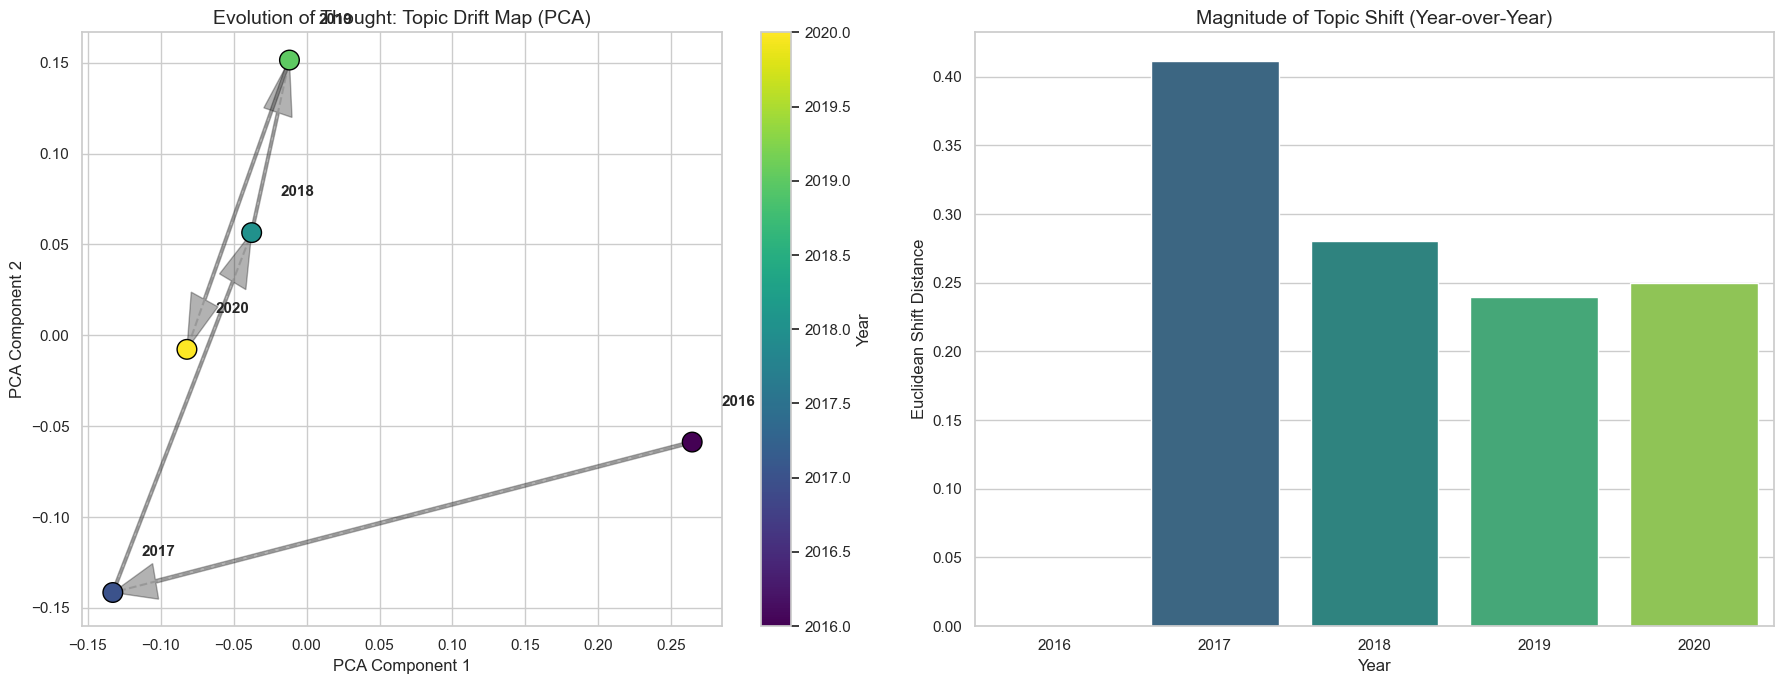

In [58]:
# --- EXECUTION ---
# Point this to one of your category folders
analyze_temporal_drift("grouped_religion")

#### Drifting Diagnostics <span style="background-color: #7caae7ec; color: black; padding: 0 5px;">Religion</span>

In [59]:
df_words = explain_drift_drivers("grouped_religion")

--- Extracting Vocabulary Drivers for grouped_religion ---
Analyzing 5 years of content: [2016, 2017, 2018, 2019, 2020]

  KEYWORD EVOLUTION (Distinctive Terms)

📅 2016: yeshua, ye, wilson, thy, poor needy, bishop, never knew, broken dreams, loves broken, too busy

📅 2017: ll each, other well, holy holy, open read, read open, holy lord, lord holy, upbeat music, upbeat, music upbeat

📅 2018: police, uh, um, jacob, braden, covenant, seattle, cops, mormonism, fucking

📅 2019: intelligence, ye, cooper, organized, sex, intelligences, blueberries, undiseptions, healing, hail

📅 2020: faith family, hosea, clark, uncommon, stuck out, security, uncommon sense, bobby, wanna, notice


In [60]:
df_words

,2016,2017,2018,2019,2020
0,yeshua,ll each,police,intelligence,faith family
1,ye,other well,uh,ye,hosea
2,wilson,holy holy,um,cooper,clark
3,thy,open read,jacob,organized,uncommon
4,poor needy,read open,braden,sex,stuck out
5,bishop,holy lord,covenant,intelligences,security
6,never knew,lord holy,seattle,blueberries,uncommon sense
7,broken dreams,upbeat music,cops,undiseptions,bobby
8,loves broken,upbeat,mormonism,healing,wanna
9,too busy,music upbeat,fucking,hail,notice


#### Temporal Analysis: <span style="background-color: #e77c93ec; color: black; padding: 0 5px;">Health</span>

--- Loading Data from grouped_health ---
Loaded 115 episodes across 5 years.


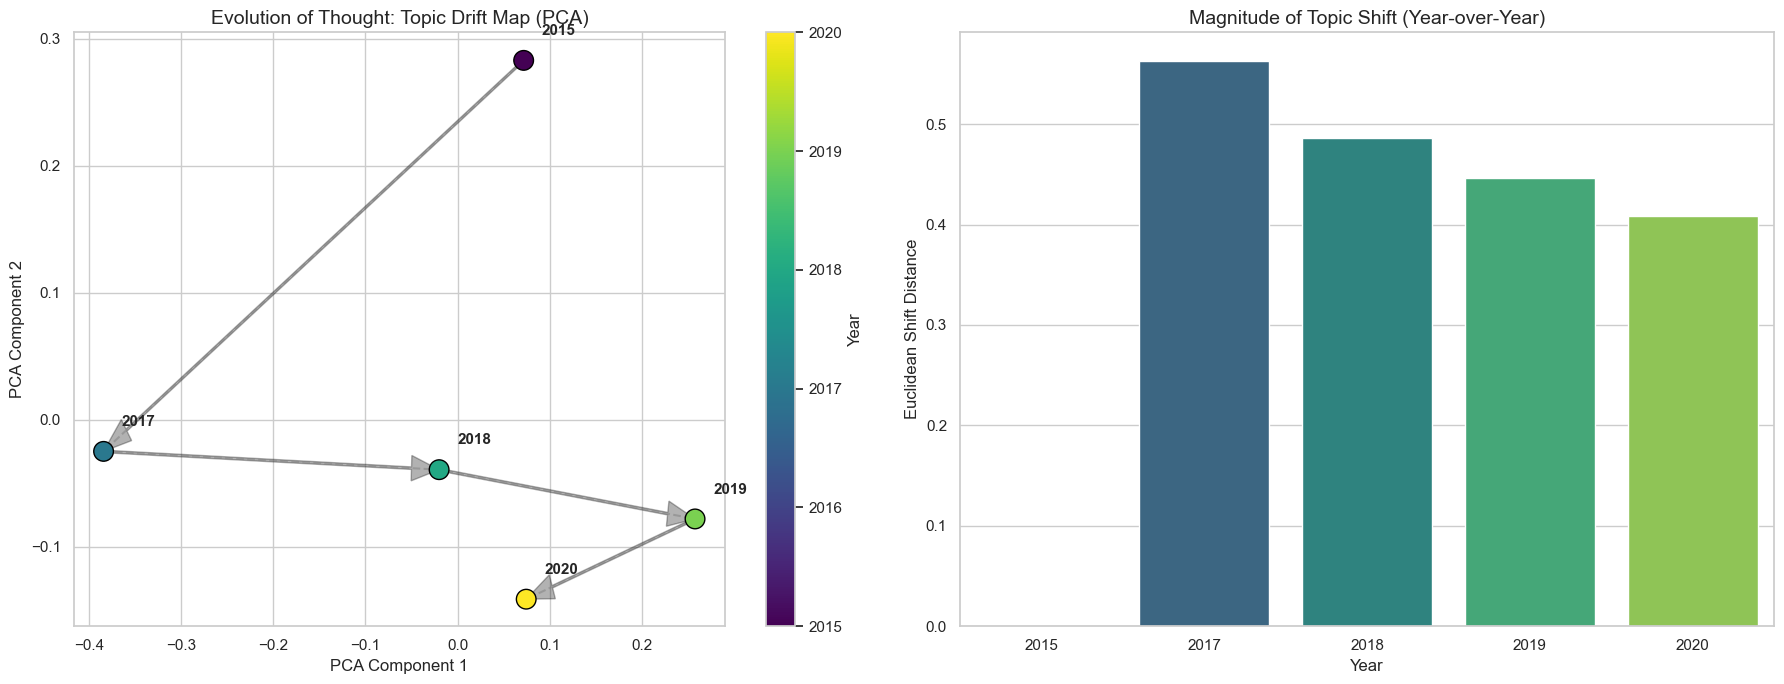

In [61]:
# --- EXECUTION ---
# Point this to one of your category folders
analyze_temporal_drift("grouped_health")

#### Drifting Diagnostics <span style="background-color: #e77c93ec; color: black; padding: 0 5px;">Health</span>

In [62]:
df_words = explain_drift_drivers("grouped_health")

--- Extracting Vocabulary Drivers for grouped_health ---
Analyzing 5 years of content: [2015, 2017, 2018, 2019, 2020]

  KEYWORD EVOLUTION (Distinctive Terms)

📅 2015: ted, ted head, moreno, ted moreno, host ted, hypnotherapist, hypnotherapy, some truth, transform, truth transform

📅 2017: sidebar, anchor, podcasting, rss feed, rss, charles, wanna, upbeat music, re gonna, hosting

📅 2018: sales, choices, own choices, our stories, linkedin, choices life, boundaries, teacher, another sales, radical responsibility

📅 2019: baby back, re baby, weight, calories, diet, fasting, intermittent, assertive, intermittent fasting, um

📅 2020: south africa, africa, lockdown, virus, vegan, economy, vaccine, discovery, patients, inside covid


In [63]:
df_words

,2015,2017,2018,2019,2020
0,ted,sidebar,sales,baby back,south africa
1,ted head,anchor,choices,re baby,africa
2,moreno,podcasting,own choices,weight,lockdown
3,ted moreno,rss feed,our stories,calories,virus
4,host ted,rss,linkedin,diet,vegan
5,hypnotherapist,charles,choices life,fasting,economy
6,hypnotherapy,wanna,boundaries,intermittent,vaccine
7,some truth,upbeat music,teacher,assertive,discovery
8,transform,re gonna,another sales,intermittent fasting,patients
9,truth transform,hosting,radical responsibility,um,inside covid
